In [265]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from copy import deepcopy


PATH = r"/Users/samuelsantiagosuarezpaez/Documents/csv/healthcare-dataset-stroke-data.csv"

df = pd.read_csv(PATH)

# First approach

In [266]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [267]:
df.head(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [268]:
df.shape

(5110, 12)

In [269]:
for i in df.select_dtypes(include=['object','str']).columns:
    print(df[i].value_counts(normalize=True))
    print("====="*10)

gender
Female    0.585910
Male      0.413894
Other     0.000196
Name: proportion, dtype: float64
ever_married
Yes    0.656164
No     0.343836
Name: proportion, dtype: float64
work_type
Private          0.572407
Self-employed    0.160274
children         0.134442
Govt_job         0.128571
Never_worked     0.004305
Name: proportion, dtype: float64
Residence_type
Urban    0.508023
Rural    0.491977
Name: proportion, dtype: float64
smoking_status
never smoked       0.370254
Unknown            0.302153
formerly smoked    0.173190
smokes             0.154403
Name: proportion, dtype: float64


In [270]:
df[df["gender"]=="Other"]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3116,56156,Other,26.0,0,0,No,Private,Rural,143.33,22.4,formerly smoked,0


In [271]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


# Valores null

In [272]:
df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [273]:
from scipy import stats

# 1. Flag de missing
df['bmi_missing'] = df['bmi'].isnull().astype(int)

# 2. ¿Se relaciona el missing con el TARGET? (¿es MNAR respecto al target?)
tab = pd.crosstab(df['bmi_missing'], df['stroke'])
chi2, p, _, _ = stats.chi2_contingency(tab)
print(f"Missing vs Stroke -> chi {chi2:.4f}")
print(f"Missing vs Stroke -> p-value: {p:.4f}")
# p < 0.05 -> el missingness SÍ depende del target -> informativo, no elimines, conserva el flag

print("====="*10)
# 3. ¿Se relaciona el missing con OTRAS variables? (¿es MAR?)
for col in ['age', 'avg_glucose_level']:
    g_missing = df.loc[df['bmi_missing']==1, col]
    g_present = df.loc[df['bmi_missing']==0, col]
    t, p = stats.ttest_ind(g_missing, g_present, equal_var=False)
    print(f"{col}: t={t:.4f}")
    print(f"{col}: p={p:.4f}")
# p < 0.05 -> el missing depende de esa variable -> MAR (ej. gente más vieja no reportó BMI)

print("====="*10)
# 4. Variables categóricas vs missing
for col in ['gender', 'smoking_status', 'work_type']:
    tab2 = pd.crosstab(df['bmi_missing'], df[col])
    chi2, p, _, _ = stats.chi2_contingency(tab2)
    print(f"{col}: chi2={chi2:.2f}")
    print(f"{col}: p={p:.4f}")

Missing vs Stroke -> chi 98.5888
Missing vs Stroke -> p-value: 0.0000
age: t=5.7260
age: p=0.0000
avg_glucose_level: t=5.0681
avg_glucose_level: p=0.0000
gender: chi2=9.27
gender: p=0.0097
smoking_status: chi2=36.52
smoking_status: p=0.0000
work_type: chi2=10.13
work_type: p=0.0382


MCAR (Missing Completely At Random / Faltantes completamente al azar)

MAR (Missing At Random / Faltantes al azar)

MNAR (Missing Not At Random / Faltantes no al azar)




Todas las variables analizadas (age, avg_glucose_level, gender, smoking_status, 
work_type) presentan relación estadísticamente significativa con los valores 
faltantes de BMI (p<0.05 en todos los casos), confirmando un mecanismo MNAR 
(el missingness también se relacia con el target, stroke).

Por lo tanto, la imputación de los faltantes se realizará mediante la mediana, 
agrupada por las variables con mayor fuerza de asociación: age (binned), 
smoking_status, y avg_glucose_level (binned). Se excluyen del agrupamiento 
gender y work_type por presentar la asociación más débil, para evitar 
fragmentar los grupos en subconjuntos demasiado pequeños.

Adicionalmente, se conserva la variable bmi_missing como flag binario, dado 
que el mecanismo MNAR implica que la ausencia del dato es en sí misma 
informativa para el modelo.

In [274]:
# 1. Bins de las variables continuas usadas para agrupar
df['age_bin'] = pd.cut(df['age'], bins=[0, 18, 40, 60, 80, 100])
df['glucose_bin'] = pd.cut(df['avg_glucose_level'], bins=[0, 90, 140, 200, 300])

# 2. Imputación por mediana, agrupada por age_bin, smoking_status, glucose_bin
df['bmi'] = df.groupby(['age_bin', 'smoking_status', 'glucose_bin'])['bmi']\
              .transform(lambda x: x.fillna(x.median()))

# 3. Fallback: grupos con muy pocos datos (mediana NaN) -> mediana global
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# 4. Verificación: no deben quedar nulos
print(df['bmi'].isnull().sum())  # debe ser 0

# 5. Verificación del flag vs target (debe conservar la señal MNAR)
print(pd.crosstab(df['bmi_missing'], df['stroke'], normalize='index'))

0
stroke              0         1
bmi_missing                    
0            0.957425  0.042575
1            0.800995  0.199005


# Outliers

In [275]:
def detectar_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (df[col] < lower) | (df[col] > upper)
    print(f"{col}: {mask.sum()} outliers | rango normal [{lower:.1f}, {upper:.1f}]")
    return mask, lower, upper

for col in ['age','bmi', 'avg_glucose_level']:
    detectar_outliers_iqr(df, col)

age: 0 outliers | rango normal [-29.0, 115.0]
bmi: 120 outliers | rango normal [9.9, 46.7]
avg_glucose_level: 627 outliers | rango normal [22.0, 169.4]


In [276]:
# ¿Los valores altos de glucosa tienen más stroke que los normales?
df['glucose_alto'] = (df['avg_glucose_level'] > 169).astype(int)
print(pd.crosstab(df['glucose_alto'], df['stroke'], normalize='index'))

df.drop(columns='glucose_alto',inplace=True)

stroke               0         1
glucose_alto                    
0             0.963194  0.036806
1             0.866029  0.133971


# EDA

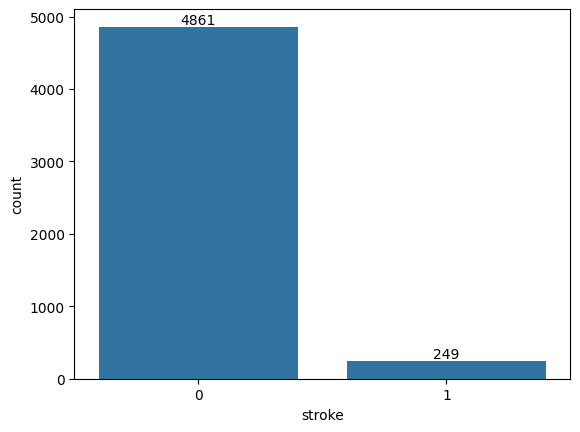

In [277]:
ax = sns.countplot(
    data=df,
    x="stroke"
)

ax.bar_label(ax.containers[0])

plt.show()

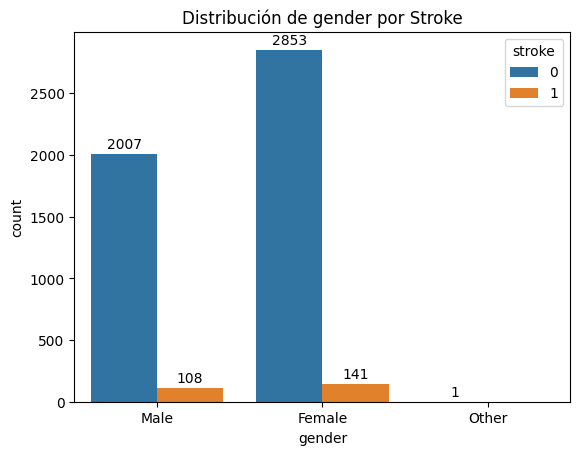

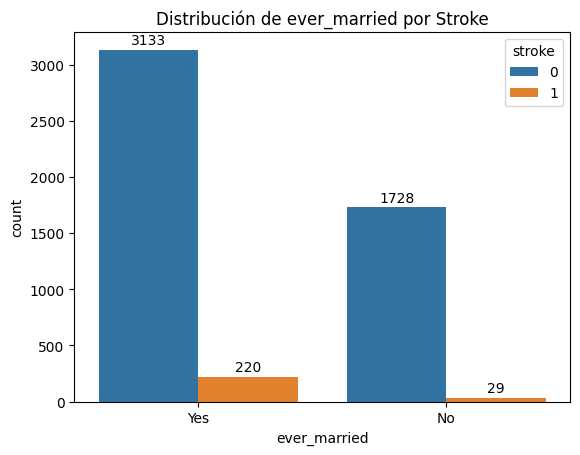

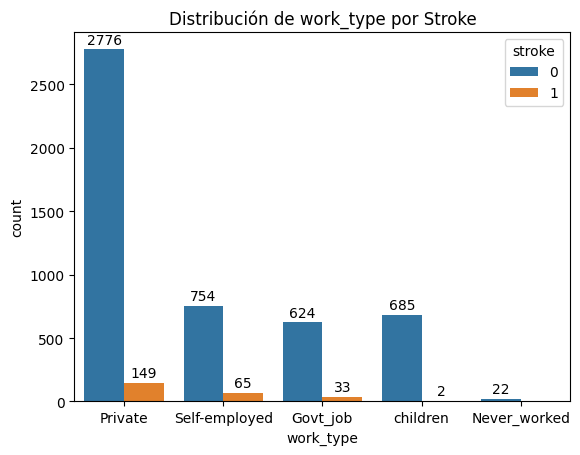

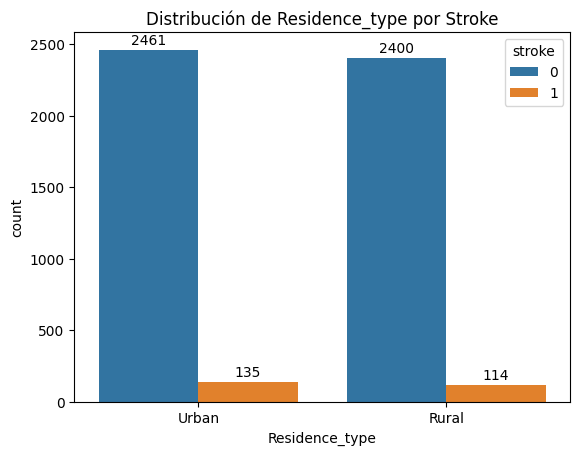

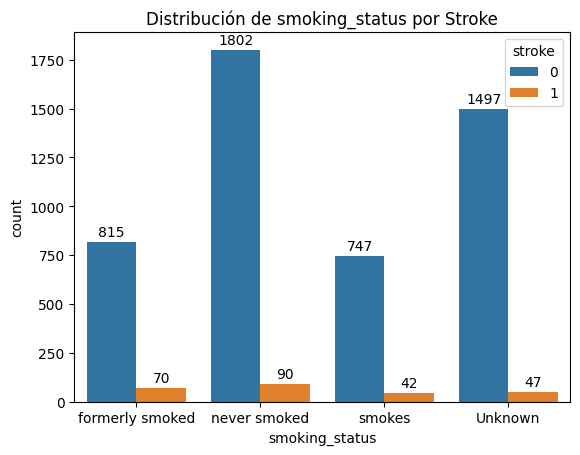

In [ ]:
# Seleccionar solo las columnas categóricas (texto/objeto)
cat = df.select_dtypes(include=["str", "object"])

# Iterar sobre el nombre de cada columna categórica
for col in cat.columns:
    # Creamos un gráfico de conteo dividiendo por 'stroke'
    ax = sns.countplot(data=df, x=col, hue="stroke")

    # Agregar las etiquetas numéricas a todos los grupos de barras (contenedores)
    for container in ax.containers:
        ax.bar_label(container, padding=2)

    # Configurar título y mostrar
    plt.title(f"Distribución de {col} por Stroke")
    plt.show()


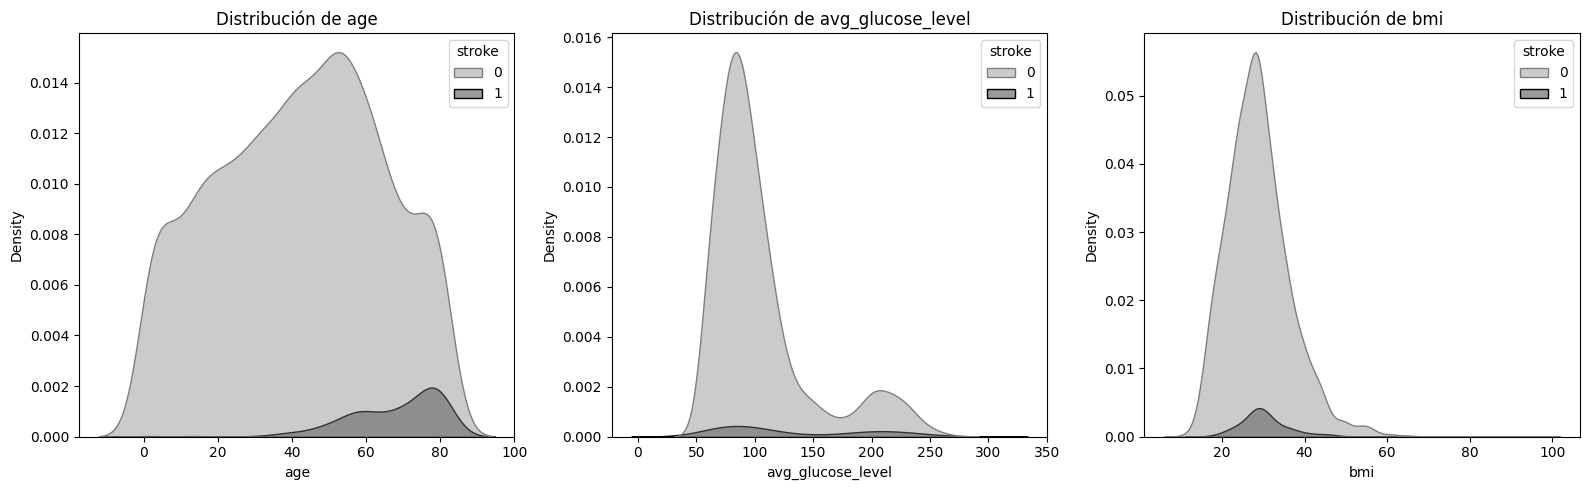

In [232]:
conts = ['age', 'avg_glucose_level', 'bmi']
colores_gris_negro = ['#7f7f7f', '#000000']

fig, axes = plt.subplots(nrows=1, ncols=len(conts), figsize=(16, 5))

for col, ax in zip(conts, axes):
    sns.kdeplot(
        data=df, 
        x=col, 
        hue='stroke', 
        palette=colores_gris_negro, 
        fill=True,      
        alpha=0.4,      
        ax=ax
    )
    ax.set_title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

/var/folders/gj/4kg1yfdd14588gmqty0qnncm0000gn/T/ipykernel_39287/1278275937.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/gj/4kg1yfdd14588gmqty0qnncm0000gn/T/ipykernel_39287/1278275937.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/gj/4kg1yfdd14588gmqty0qnncm0000gn/T/ipykernel_39287/1278275937.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


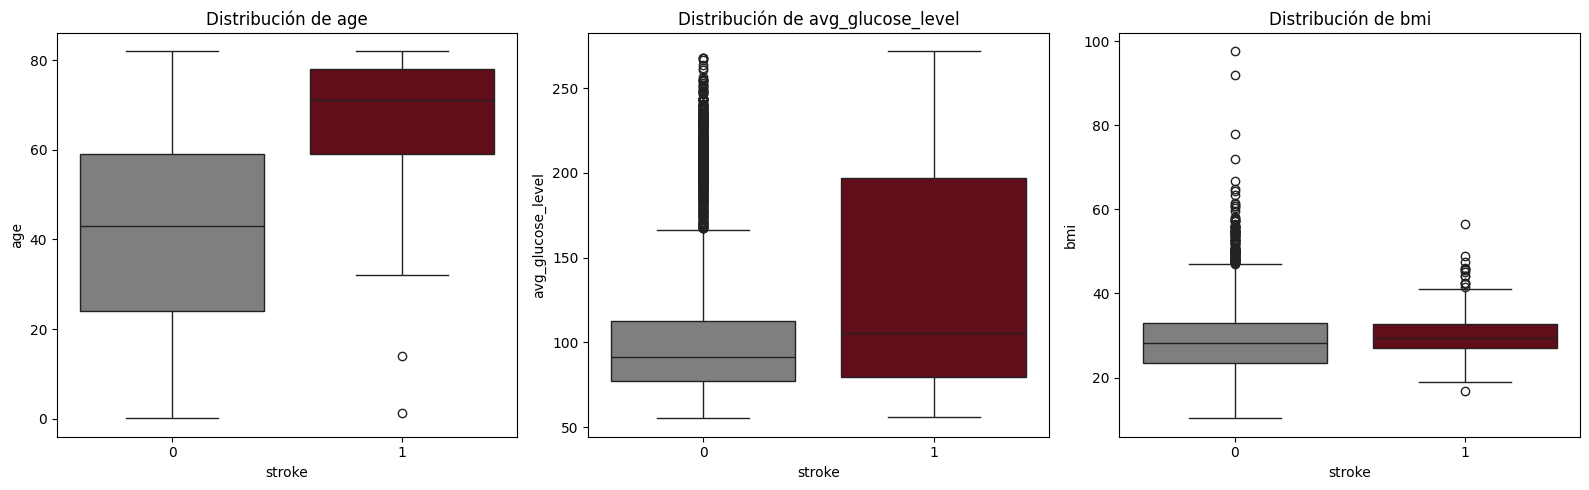

In [233]:
conts = ['age', 'avg_glucose_level', 'bmi']
colores_gris_negro = ['#7f7f7f', '#700010']

fig, axes = plt.subplots(nrows=1, ncols=len(conts), figsize=(16, 5))

for col, ax in zip(conts, axes):
    sns.boxplot(
        data=df, 
        x='stroke', 
        y=col,
        palette=colores_gris_negro,        
        ax=ax
    )
    ax.set_title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

# Base line

In [308]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import GridSearchCV
from copy import deepcopy

## Train test

In [293]:
df_t = deepcopy(df)

df_t["high_glucose"] = np.where(df_t["avg_glucose_level"] >= 200, 1, 0)

c1_hombres_20_64 = (df_t["gender"] == 'Male') & (df_t["age"].between(20, 64)) & (df_t["bmi"].between(21, 25))
c1_mujeres_20_64 = (df_t["gender"] == 'Female') & (df_t["age"].between(20, 64)) & (df_t["bmi"].between(19, 24))

c2_hombres_mas_64 = (df_t["gender"] == 'Male') & (df_t["age"] > 64) & (df_t["bmi"].between(24, 29))
c2_mujeres_mas_64 = (df_t["gender"] == 'Female') & (df_t["age"] > 64) & (df_t["bmi"].between(24, 30))

c3_ninos_2_5 = (df_t["age"].between(2, 5)) & (df_t["bmi"].between(16, 18))

c4_ninos_6_10 = (df_t["age"].between(6, 10)) & (df_t["bmi"].between(19, 24))

# 2. Combinamos todas las condiciones de "BMI Normal" con el operador OR (|)
bmi_normal = (
    c1_hombres_20_64 | 
    c1_mujeres_20_64 | 
    c2_hombres_mas_64 | 
    c2_mujeres_mas_64 | 
    c3_ninos_2_5 | 
    c4_ninos_6_10
)

# 3. Asignamos 0 si el BMI está en el rango normal, y 1 si está fuera de límite (alerta)
df_t["bmi_alert"] = np.where(bmi_normal, 0, 1)

df_t.head(3)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_missing,age_bin,glucose_bin,high_glucose,bmi_alert
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.60,formerly smoked,1,0,"(60, 80]","(200, 300]",1,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,30.65,never smoked,1,1,"(60, 80]","(200, 300]",1,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.50,never smoked,1,0,"(60, 80]","(90, 140]",0,1


In [300]:
df_t.select_dtypes(exclude=["str","object"]).columns

Index(['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level',
       'bmi', 'stroke', 'bmi_missing', 'age_bin', 'glucose_bin',
       'high_glucose', 'bmi_alert'],
      dtype='str')

In [301]:
X = df_t.drop(columns=["age_bin","glucose_bin","stroke","id"])
Y = df_t["stroke"]

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42, stratify=Y)

# Columnas por tipo
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type','smoking_status']
num_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level','bmi', 'bmi_missing','high_glucose', 'bmi_alert']

pre_tree = ColumnTransformer([
    ('cat',OneHotEncoder(handle_unknown='ignore'),cat_cols)
],remainder='passthrough')

pre_linear = ColumnTransformer([
    ('cat',OneHotEncoder(handle_unknown='ignore'),cat_cols),
    ('num',StandardScaler(), num_cols)
])


In [304]:
pipe_dt = Pipeline([
    ('pre',pre_tree),
    ('model',DecisionTreeClassifier(random_state=42))
])

pipe_rf = Pipeline([
    ('pre',pre_tree),
    ('model',RandomForestClassifier(random_state=42))
])

pipe_xg = Pipeline([
    ('pre',pre_tree),
    ('model',XGBClassifier(random_state=42))
])

pipe_log = Pipeline([
    ('pre',pre_linear),
    ('model',LogisticRegression(max_iter=1000))
])

In [305]:
pipe_dt.fit(X_train, Y_train)
pipe_rf.fit(X_train, Y_train)
pipe_xg.fit(X_train, Y_train)
pipe_log.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['gender','age','hypertension',...,'bmi_missing','high_glucose', 'bmi_alert']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all rem

In [307]:
modelos = {
    'Decision Tree': pipe_dt,
    'Random Forest': pipe_rf,
    'XGBoost': pipe_xg,
    'Logistic Regression': pipe_log
}

for nombre, pipe in modelos.items():
    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]
    print(f"\n=== {nombre} ===")
    print(classification_report(Y_test, preds))
    print(f"AUC-ROC: {roc_auc_score(Y_test, probs):.4f}")


=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       972
           1       0.20      0.18      0.19        50

    accuracy                           0.93      1022
   macro avg       0.58      0.57      0.58      1022
weighted avg       0.92      0.93      0.92      1022

AUC-ROC: 0.5720

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

AUC-ROC: 0.7615

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       972
           1       0.20      0.06      0.09        50

    accuracy                           0.94      1022
   macro avg       0.58      0.52

## optimización de hiperparámetros

In [312]:
param_rf = {
    'model__n_estimators':[100,300],
    'model__max_depth':[5,10,None],
    'model__class_weight': ['balanced', 'balanced_subsample']
}

grid_rf = GridSearchCV(pipe_rf,param_rf,scoring='recall',cv=5, n_jobs=-1)
grid_rf.fit(X_train,Y_train)

param_dt = {
    'model__max_depth':[3,5,10,None],
    'model__class_weight':['balanced']
}

grid_dt = GridSearchCV(pipe_dt,param_dt,scoring='recall',cv=5, n_jobs=-1)
grid_dt.fit(X_train,Y_train)

param_log = {
    'model__C':[0.01,0.1,1,10],
    'model__class_weight':['balanced']
}

grid_log = GridSearchCV(pipe_log,param_log,scoring='recall', cv=5, n_jobs=-1)
grid_log.fit(X_train,Y_train)

scale_pos = (Y_train==0).sum() / (Y_train==1).sum()
param_xg = {
    'model__max_depth':[3,5,7],
    'model__n_estimators':[100,300],
    'model__scale_pos_weight':[1,scale_pos]
}

grid_gx = GridSearchCV(pipe_xg,param_xg,scoring='recall',cv=5, n_jobs=-1)
grid_gx.fit(X_train,Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 300], 'model__scale_pos_weight': [1, np.float64(19.542713567839197)]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.

In [314]:
modelos_ht = {
    'Decision_tree_tuned':grid_dt.best_estimator_,
    'Log_tuned':grid_log.best_estimator_,
    'Xgb tuned': grid_gx.best_estimator_,
    'Ran forest tuned': grid_rf.best_estimator_
}

for nombre, modelo in modelos_ht.items():
    preds = modelo.predict(X_test)
    probs = modelo.predict_proba(X_test)[:,1]
    print(f'\n==== {nombre} ====')
    print(classification_report(Y_test,preds))
    print(f"AUC ROC: {roc_auc_score(Y_test, probs):.4f}")



==== Decision_tree_tuned ====
              precision    recall  f1-score   support

           0       0.99      0.57      0.72       972
           1       0.09      0.84      0.16        50

    accuracy                           0.58      1022
   macro avg       0.54      0.70      0.44      1022
weighted avg       0.94      0.58      0.69      1022

AUC ROC: 0.8065

==== Log_tuned ====
              precision    recall  f1-score   support

           0       0.99      0.76      0.86       972
           1       0.15      0.82      0.25        50

    accuracy                           0.76      1022
   macro avg       0.57      0.79      0.56      1022
weighted avg       0.95      0.76      0.83      1022

AUC ROC: 0.8371

==== Xgb tuned ====
              precision    recall  f1-score   support

           0       0.97      0.87      0.92       972
           1       0.15      0.44      0.22        50

    accuracy                           0.85      1022
   macro avg       0.56